# Ablation Study

This notebooks compares the best fusion model with the best single antenna models.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scienceplots  # noqa: F401  # noqa: F401
import torch

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.evaluator import Evaluator
from csi_vae.jobs.job import init_rng, make_dataloader
from csi_vae.studies import StudyResult, get_best_model, read_studies

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300})

settings = JobSettings()

OUT_DIR = Path("../out")
WI_HAR_LAUNCH_DIR = OUT_DIR / "fusion"
WI_HAR_WEIGHTS_DIR = Path("../weights/fusion")
SINGLE_LAUNCH_DIRS = [OUT_DIR / f"antenna_{i}" for i in range(settings.n_antennas)]
SINGLE_WEIGHTS_DIR = [Path(f"../weights/antenna_{i}") for i in range(settings.n_antennas)]
PLOTS_DIR = OUT_DIR / "plots"
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

PLOTS_DIR.mkdir(exist_ok=True)

In [5]:
wi_har_studies = read_studies(str(WI_HAR_LAUNCH_DIR))
single_studies = [read_studies(str(launch_dir)) for launch_dir in SINGLE_LAUNCH_DIRS]

wi_har_best_model = get_best_model(wi_har_studies)
single_best_models = [get_best_model(studies) for studies in single_studies]

In [6]:
def _get_best_gaussians(single_best_results: list[StudyResult]) -> list[vae.SingleAntenna]:
    single_antennas = []
    for i, result in enumerate(single_best_results):
        model_path = (
            SINGLE_WEIGHTS_DIR[i]
            / "l2"
            / f"t{single_best_models[i].trial_number}"
            / f"s{single_best_models[i].seed}"
            / "delayed_fusion.pt"
        )
        single_antenna = vae.SingleAntenna(
            settings.window_size,
            settings.n_subcarriers,
            2,
            vae.CONV_SPECS[result.params["conv_layers_spec"]],
        ).to(DEVICE)
        delayed_fusion = fusion.Delayed(
            [single_antenna],
            2,
            settings.n_activities,
            result.params["n_fusion_layers"],
            result.params["fusion_dropout"],
        ).to(DEVICE)
        delayed_fusion.load_state_dict(torch.load(model_path))

        single_antennas.append(single_antenna)

    return single_antennas


fusion_of_best_results = []
for seed in wi_har_best_model.accuracies_per_seed:
    init_rng(int(seed))

    batch_size = 2 ** wi_har_best_model.params["batch_size_exp"]
    train_ds, val_ds, test_ds = dataset.load(
        dataset_path=Path("../") / settings.dataset_path,
        window_size=settings.window_size,
        n_activities=settings.n_activities,
        stride=settings.stride,
    )
    train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=int(seed))
    val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=int(seed))
    test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=int(seed))

    ablation_delayed_fusion = fusion.Delayed(
        _get_best_gaussians(single_best_models),
        wi_har_best_model.n_gaussians,
        settings.n_activities,
        wi_har_best_model.params["n_fusion_layers"],
        wi_har_best_model.params["fusion_dropout"],
    ).to(DEVICE)
    trainer = fusion.Trainer(
        ablation_delayed_fusion,
        train_dl,
        val_dl,
        fusion.TrainerParams(
            lr=wi_har_best_model.params["lr"],
            early_stop_patience=settings.early_stop_patience,
            early_stop_warmup_epochs=settings.early_stop_warmup_epochs,
        ),
        DEVICE,
    )
    trainer.train(settings.n_epochs)

    accuracy = Evaluator(ablation_delayed_fusion, test_dl, DEVICE).evaluate()
    fusion_of_best_results.append(accuracy)

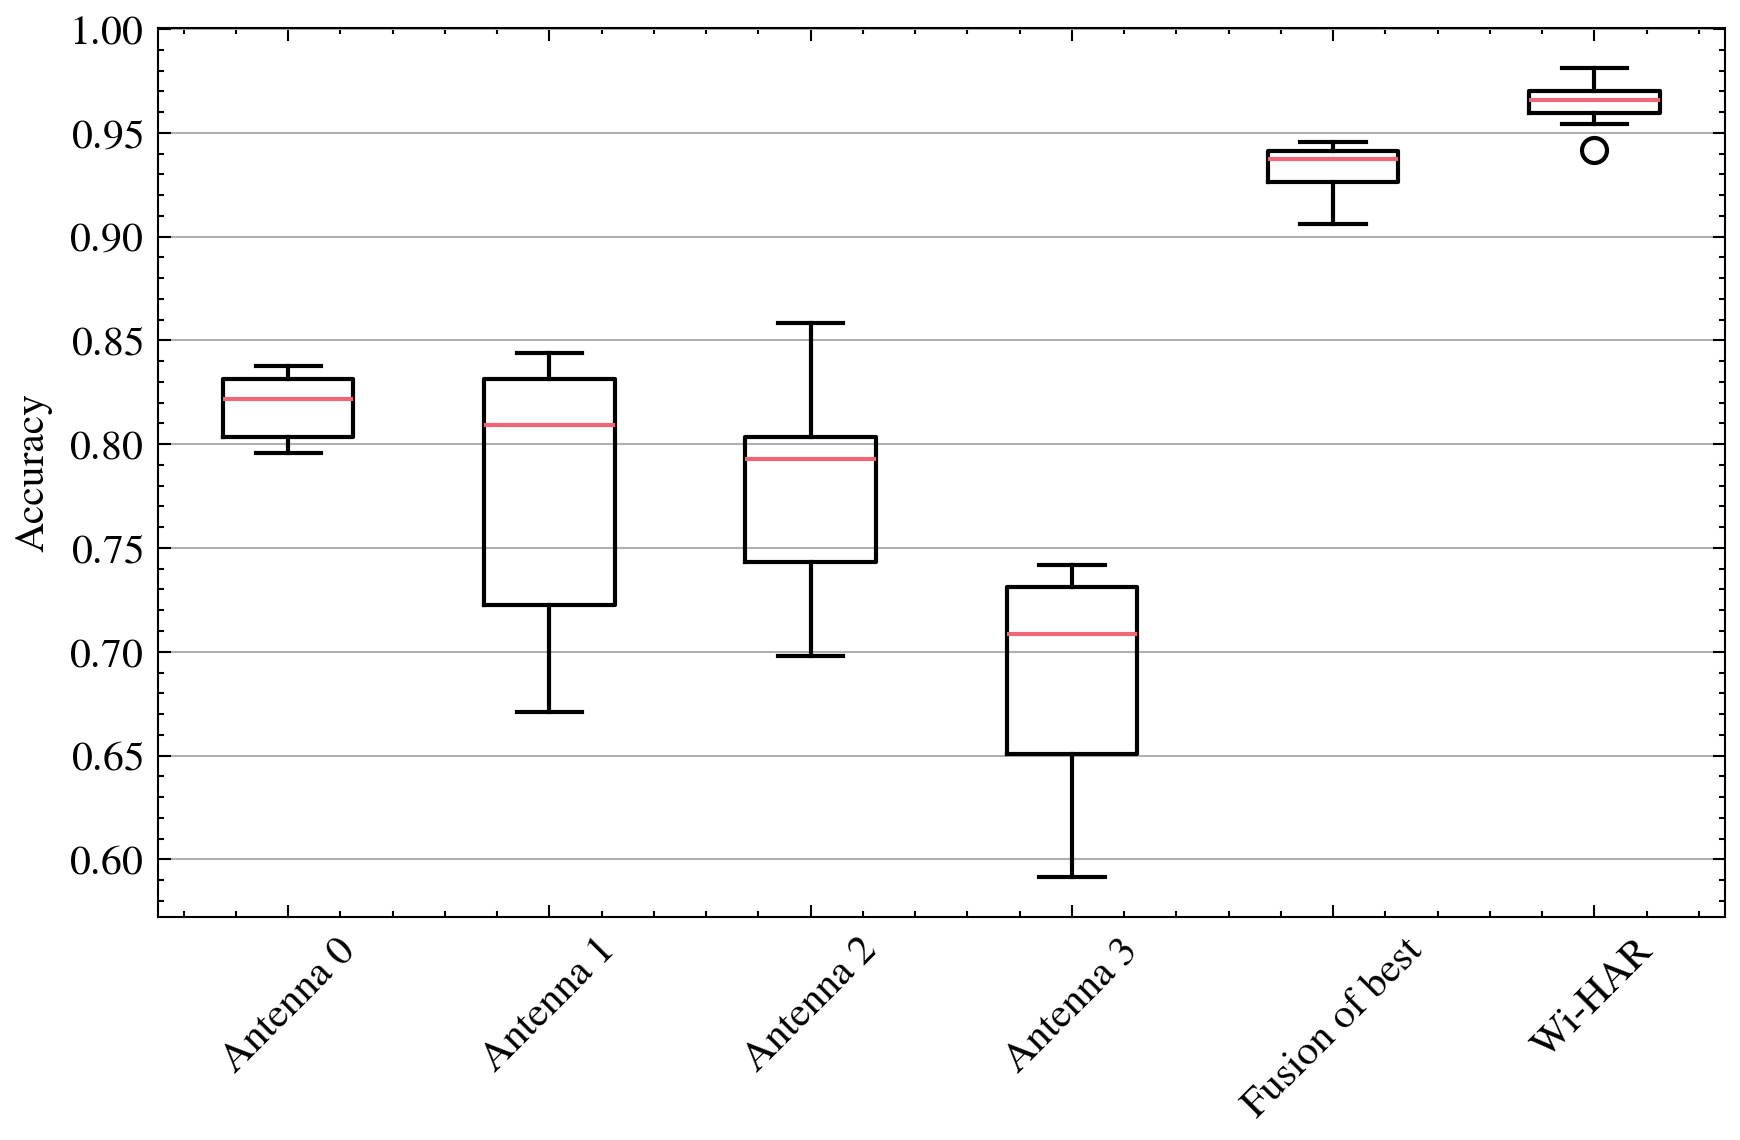

In [7]:
wi_har_results = list(wi_har_best_model.accuracies_per_seed.values())
single_results = [list(model.accuracies_per_seed.values()) for model in single_best_models]

data = [single_results[a] for a in range(len(single_results))] + [fusion_of_best_results, wi_har_results]
labels = [f"Antenna {a}" for a in range(len(single_results))] + ["Fusion of best", "Wi-HAR"]

plt.figure(figsize=(6, 4))
plt.boxplot(data, tick_labels=labels)

plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y")
plt.savefig(PLOTS_DIR / "ablation.pdf")
plt.show()

In [8]:
ablation_df = []

for a in range(len(single_results)):
    single = {
        "name": f"Antenna {a}",
        "median": torch.median(torch.tensor(single_results[a])).item(),
        "p25": torch.quantile(torch.tensor(single_results[a]), 0.25).item(),
        "p75": torch.quantile(torch.tensor(single_results[a]), 0.75).item(),
    }
    ablation_df.append(single)

fusion_of_best = {
    "name": "Fusion of best",
    "median": torch.median(torch.tensor(fusion_of_best_results)).item(),
    "p25": torch.quantile(torch.tensor(fusion_of_best_results), 0.25).item(),
    "p75": torch.quantile(torch.tensor(fusion_of_best_results), 0.75).item(),
}
ablation_df.append(fusion_of_best)

wi_har = {
    "name": "Wi-HAR",
    "median": torch.median(torch.tensor(wi_har_results)).item(),
    "p25": torch.quantile(torch.tensor(wi_har_results), 0.25).item(),
    "p75": torch.quantile(torch.tensor(wi_har_results), 0.75).item(),
}
ablation_df.append(wi_har)

ablation_df = pd.DataFrame(ablation_df)
ablation_df

,name,median,p25,p75
0,Antenna 0,0.814583,0.803646,0.831250
1,Antenna 1,0.806250,0.722396,0.831250
2,Antenna 2,0.787500,0.743229,0.803646
3,Antenna 3,0.708333,0.650521,0.731250
4,Fusion of best,0.937500,0.926562,0.941146
5,Wi-HAR,0.964583,0.959375,0.970313
